In [ ]:
import matplotlib.font_manager as fm

# Lista todas as fontes disponíveis e filtra as que contém "Author"
fontes = [f.name for f in fm.fontManager.ttflist if "Author" in f.name]
print("Fontes encontradas:", set(fontes))

Sucesso: Arquivo salvo em c:\Users\P0165559\Documents\Relatorios\tjmg_relatorio_diagnostico\data\processed\canvas_images\figura_26.png


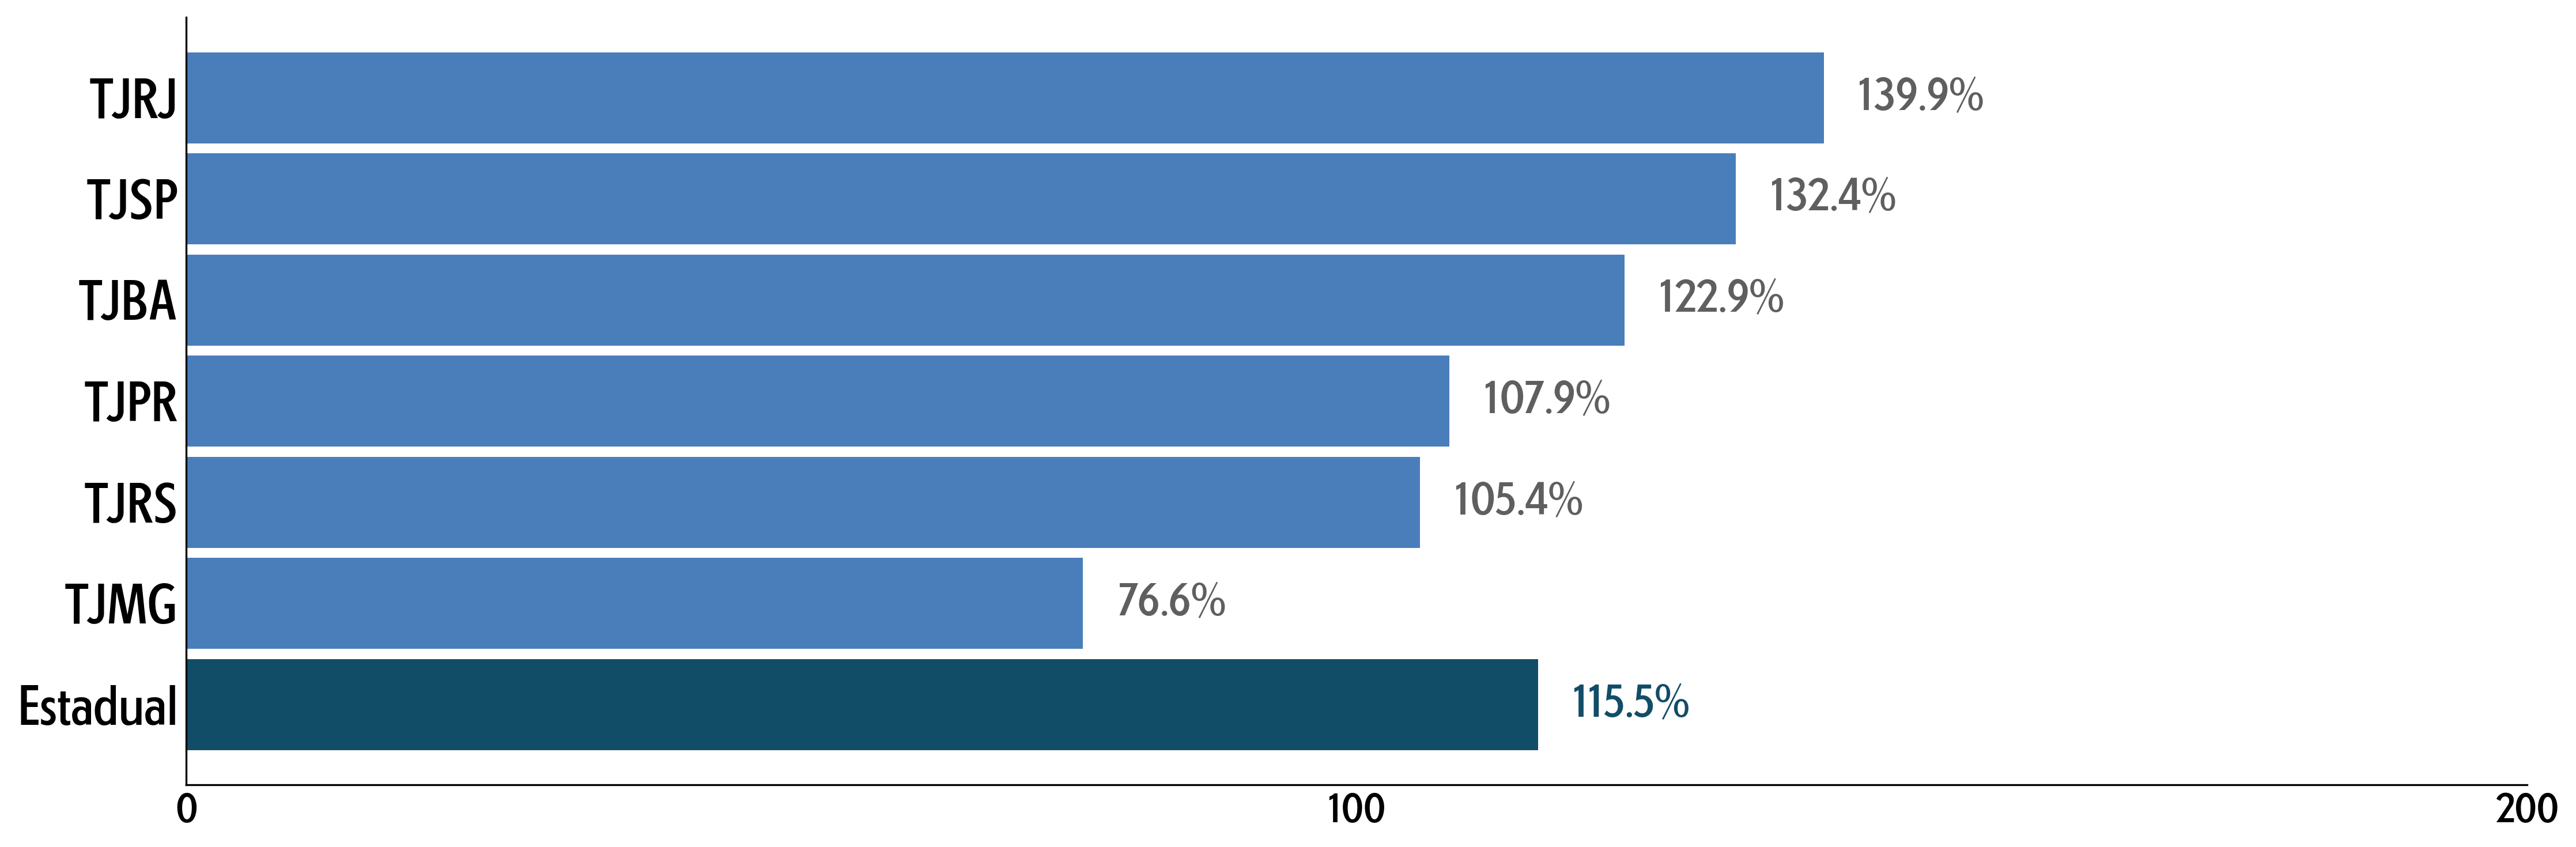

In [57]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. GESTÃO DE CAMINHOS
try:
    diretorio_notebook = os.path.dirname(os.path.abspath(__file__))
except NameError:
    diretorio_notebook = os.getcwd()

caminho_fonte = os.path.join(diretorio_notebook, 'Esseltub Regular.otf')
caminho_salvamento = os.path.abspath(os.path.join(diretorio_notebook, '..', 'data', 'processed', 'canvas_images', 'figura_26.png'))

os.makedirs(os.path.dirname(caminho_salvamento), exist_ok=True)

# 2. DEFINIÇÃO DE TAMANHOS DE FONTE
size_eixo_y = 22    # Nomes dos tribunais
size_eixo_x = 16    # Números da escala (0, 100, 200)
size_rotulos = 18   # Valores percentuais ao lado das barras
size_titulo = 18    # Título (se houver)

prop_y = fm.FontProperties(fname=caminho_fonte, size=size_eixo_y)
prop_x = fm.FontProperties(fname=caminho_fonte, size=size_eixo_x)
prop_rotulos = fm.FontProperties(fname=caminho_fonte, size=size_rotulos)
prop_titulo = fm.FontProperties(fname=caminho_fonte, size=size_titulo)

# 3. DADOS
tribunais = ['TJRJ', 'TJSP', 'TJBA', 'TJPR', 'TJRS', 'TJMG', 'Estadual']
valores = [139.9, 132.4, 122.9, 107.9, 105.4, 76.6, 115.5]

# 4. DEFINIÇÃO DE CORES DINÂMICAS
# Criamos uma lista de cores: azul padrão para todos, exceto 'Estadual'
cores = ['#124d67' if trib == 'Estadual' else '#4a7ebb' for trib in tribunais]

# 5. CONSTRUÇÃO DO GRÁFICO
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

# Criar barras com a lista de cores definida
bars = ax.barh(tribunais, valores, color=cores, height=0.9)
ax.invert_yaxis()

# 6. RÓTULOS DAS BARRAS
for bar, trib in zip(bars, tribunais):
    width = bar.get_width()
    # A cor do texto também acompanha a barra se for Estadual
    cor_texto = '#124d67' if trib == 'Estadual' else '#5f5f5f'
    
    ax.text(width + 3, bar.get_y() + bar.get_height()/2, 
            f'{float(width):.1f}%', 
            va='center', ha='left', 
            color=cor_texto, 
            fontproperties=prop_rotulos)

# 7. CONFIGURAÇÃO DOS EIXOS
ax.set_xlim(0, 200)
ax.set_xticks([0, 100, 200])

for label in ax.get_yticklabels():
    label.set_fontproperties(prop_y)

for label in ax.get_xticklabels():
    label.set_fontproperties(prop_x)

# 8. ESTÉTICA
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(axis='both', length=0)

# 9. SALVAMENTO E EXIBIÇÃO
plt.tight_layout()
plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
print(f"Sucesso: Arquivo salvo em {caminho_salvamento}")
plt.show()

In [ ]:
pip install matplotlib